In [15]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt
import json


In [16]:
#%pip install -e ..

In [17]:
from proj2dhullsampler.pipeline import build_case, default_worker_count

In [18]:
with open('apply_config.json', 'r') as file:
    config = json.load(file)

In [19]:
config

{'mode': 'python',
 'working_dir': '/glade/work/qingyuany/repo_data/',
 'case_name': 'proj2d_example_original_ppe6',
 'result_name': 'sample1',
 'data_paths': {'obs_nc': '/glade/u/home/qingyuany/repos/spatialtuning/data/nc_based_data/interpolated_obs.nc',
  'obs_tab': None,
  'para': '/glade/work/qingyuany/camml_re/v0/parameter_34_100.csv',
  'ppe_nc': '/glade/work/qingyuany/camml_re/v0/initial_ppe.nc',
  'ppe_tab': None},
 'obs_dict': {'SWCF': 'swcrf_toa',
  'LWCF': 'lwcrf_toa',
  'TMQ': 'pwv',
  'FLUT': 'olr',
  'PRECT': 'pr',
  'FSNTOA': 'swabs_toa'},
 'lat_bins': {'start': -70, 'stop': 70, 'step': 5},
 'manual_regions': [{'nm': 'PRECT',
   'lat_min': 4,
   'lat_max': 7,
   'lon_min': 1,
   'lon_max': 359},
  {'nm': 'SWCF', 'lat_min': 4, 'lat_max': 7, 'lon_min': 1, 'lon_max': 359}],
 'n_sample': 100000,
 'prepare_case': {'n_cpus': 10, 'threshold_levels': [2.0]},
 'threshold_level': 2.0,
 'emultor_error_ratio_threshold': 0.2,
 'visualize_check_vars': ['SWCF_zonal_35to40', 'LWCF_zonal

In [20]:
working_dir = config["working_dir"]
case_name = config["case_name"]
result_name = config["result_name"]

Worker count: prepare_case.n_cpus=10 (job allocation reports 16 CPUs available; an explicit config value, if set, takes precedence)
Case directory does not exist yet; creating and preparing it.
Start creating new case
Check on nan variables passes: nan variables matching between obs and simulation
obs_shape: (162,), and ppe shape: (100, 162)
Manual and zonal indices match
obs and ppe variable names match


/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

5 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
3 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
3 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
2 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
3 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
2 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
3 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
3 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 


/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

3 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
5 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
5 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
5 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
5 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
2 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
4 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
4 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 


...

5 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
5 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
3 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
3 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
3 out of 1

/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

6 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
3 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
5 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
4 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
5 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
5 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
2 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
0 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
4 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 


/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/work/qingyuany/conda-envs/ml_env/lib/python3.11/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn

3 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
0 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
1 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
2 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
3 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
5 out of 100 samples are outside the range defined by the GP uncertainty and specified threshold. 
<class 'pandas.core.frame.DataFrame'>
                          0
SWCF_zonal_-70to-65    0.01
SWCF_zonal_-65to-60    0.01
SWCF_zonal_-60to-55    0.05
SWCF_zonal_-55to-50    0.02
SWCF_zonal_-50to-45    0.02
..

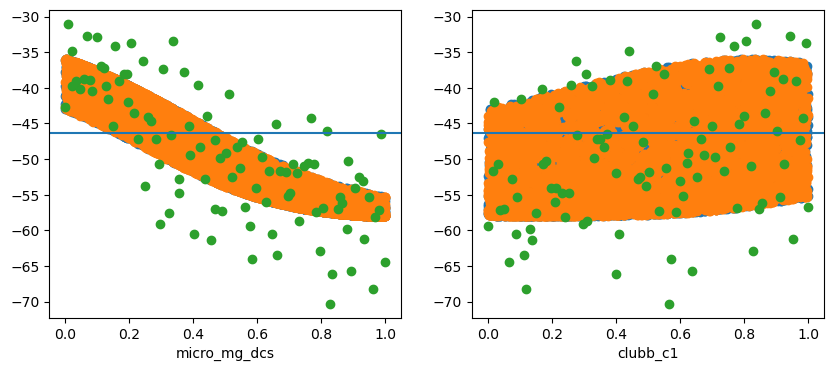

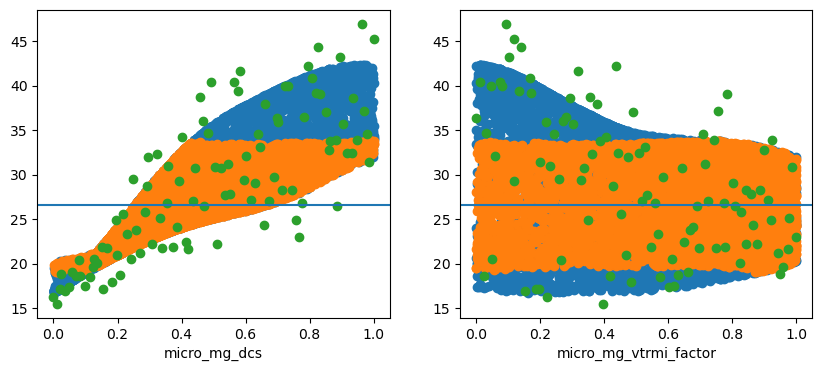

In [21]:
# Loads data per config["data_paths"], then either creates+prepares a new
# case or loads an existing one from working_dir/case_name - same logic
# run_apply.py uses for batch (PBS) runs, so both stay in sync automatically.
# mode="notebook" (rather than config["mode"]) so figures show inline here
# regardless of what mode the batch config was written for.
test_case = build_case(config, mode="notebook")

In [22]:
vars_to_drop = config["vars_to_drop"]
emultor_error_ratio_threshold = config["emultor_error_ratio_threshold"]
n_survive_threshold = config["n_survive_threshold"]
n_survive_threshold_2d = config["n_survive_threshold_2d"]
added_num = config["added_number_for_pairs"]
n_var_thre = config["n_var_thre"]
max_workers = config.get("max_workers", default_worker_count())
n_pts = config["n_pts"]
n_threshold = config["n_threshold"]
sample_threshold = config["sample_threshold"]
n_max = config["n_max"]
top_n = config["top_n"]

In [23]:
test_case.drop_by_name(vars_to_drop)
test_case.drop_by_emulator_performance(emultor_error_ratio_threshold)
test_case.drop_by_n_survive(n_survive_threshold)

Drop variables [] based on hand selection
Drop variables [] based on emulator perfornace (error ratio of 0.2 as threshold)
Drop variables ['FSNTOA_zonal_-40to-35', 'SWCF_zonal_-30to-25', 'PRECT_zonal_15to20', 'SWCF_zonal_-40to-35', 'PRECT_zonal_20to25', 'SWCF_zonal_35to40', 'PRECT_zonal_-60to-55', 'SWCF_zonal_30to35', 'FSNTOA_zonal_-30to-25', 'SWCF_zonal_-35to-30', 'FSNTOA_zonal_-35to-30', 'FSNTOA_zonal_30to35', 'PRECT_zonal_-25to-20'] because they do not help constrain the parameters
Drop variables ['SWCF_zonal_-70to-65', 'PRECT_zonal_-70to-65'] because they constrain the parmaeters too much


In [24]:
test_case.remove_var2d_auto(n_survive_threshold_2d, added_num=added_num)
test_case.drop_by_nvar_per_pair(n_var_thre)

micro_mg_vtrmi_factor                    and micro_mg_dcs                            :        1
There are 1 groups that have no overlapping within own groups
Drop variable ['PRECT_zonal_10to15']
There are 0 groups that have no overlapping within own groups
No non-overlapping variables at this stage for the variables sharing the same 2 sensitive parameters
Finished dropping variables
Drop variables ['PRECT_zonal_0to5', 'PRECT_zonal_60to65', 'FSNTOA_zonal_35to40'] because when grouped together, they contribute to too little surviving ensemble members


In [25]:
test_case.prepare_for_sampling(n_pts=config['testing_n_pts'], n_threshold=config['testing_n_threshold'], sample_threshold=config['testing_sample_threshold'], max_workers=max_workers)
test_case.draw(n_pts=n_pts, n_threshold=n_threshold, sample_threshold=sample_threshold, max_workers=max_workers, n_max=n_max)

Finish constructing the 2d polygons/convex hulls
Running ('micro_mg_vtrmi_factor', 'micro_mg_dcs'), the 0th simulation
There is overlap for ('micro_mg_vtrmi_factor', 'micro_mg_dcs'). Proceed to the next parameter pair
Running ('micro_mg_dcs', 'microp_aero_wsub_scale'), the 1th simulation
There is overlap for ('micro_mg_dcs', 'microp_aero_wsub_scale'). Proceed to the next parameter pair
Running ('micro_mg_dcs', 'microp_aero_wsubi_scale'), the 2th simulation
There is overlap for ('micro_mg_dcs', 'microp_aero_wsubi_scale'). Proceed to the next parameter pair
Running ('micro_mg_vtrmi_factor', 'zmconv_capelmt'), the 3th simulation
There is overlap for ('micro_mg_vtrmi_factor', 'zmconv_capelmt'). Proceed to the next parameter pair
Running ('micro_mg_vtrmi_factor', 'clubb_c2rt'), the 4th simulation
There is overlap for ('micro_mg_vtrmi_factor', 'clubb_c2rt'). Proceed to the next parameter pair
Running ('micro_mg_vtrmi_factor', 'zmconv_tiedke_add'), the 5th simulation
There is overlap for ('mi

In [26]:
test_case.save_samples_specifications(result_name, top_n = top_n)

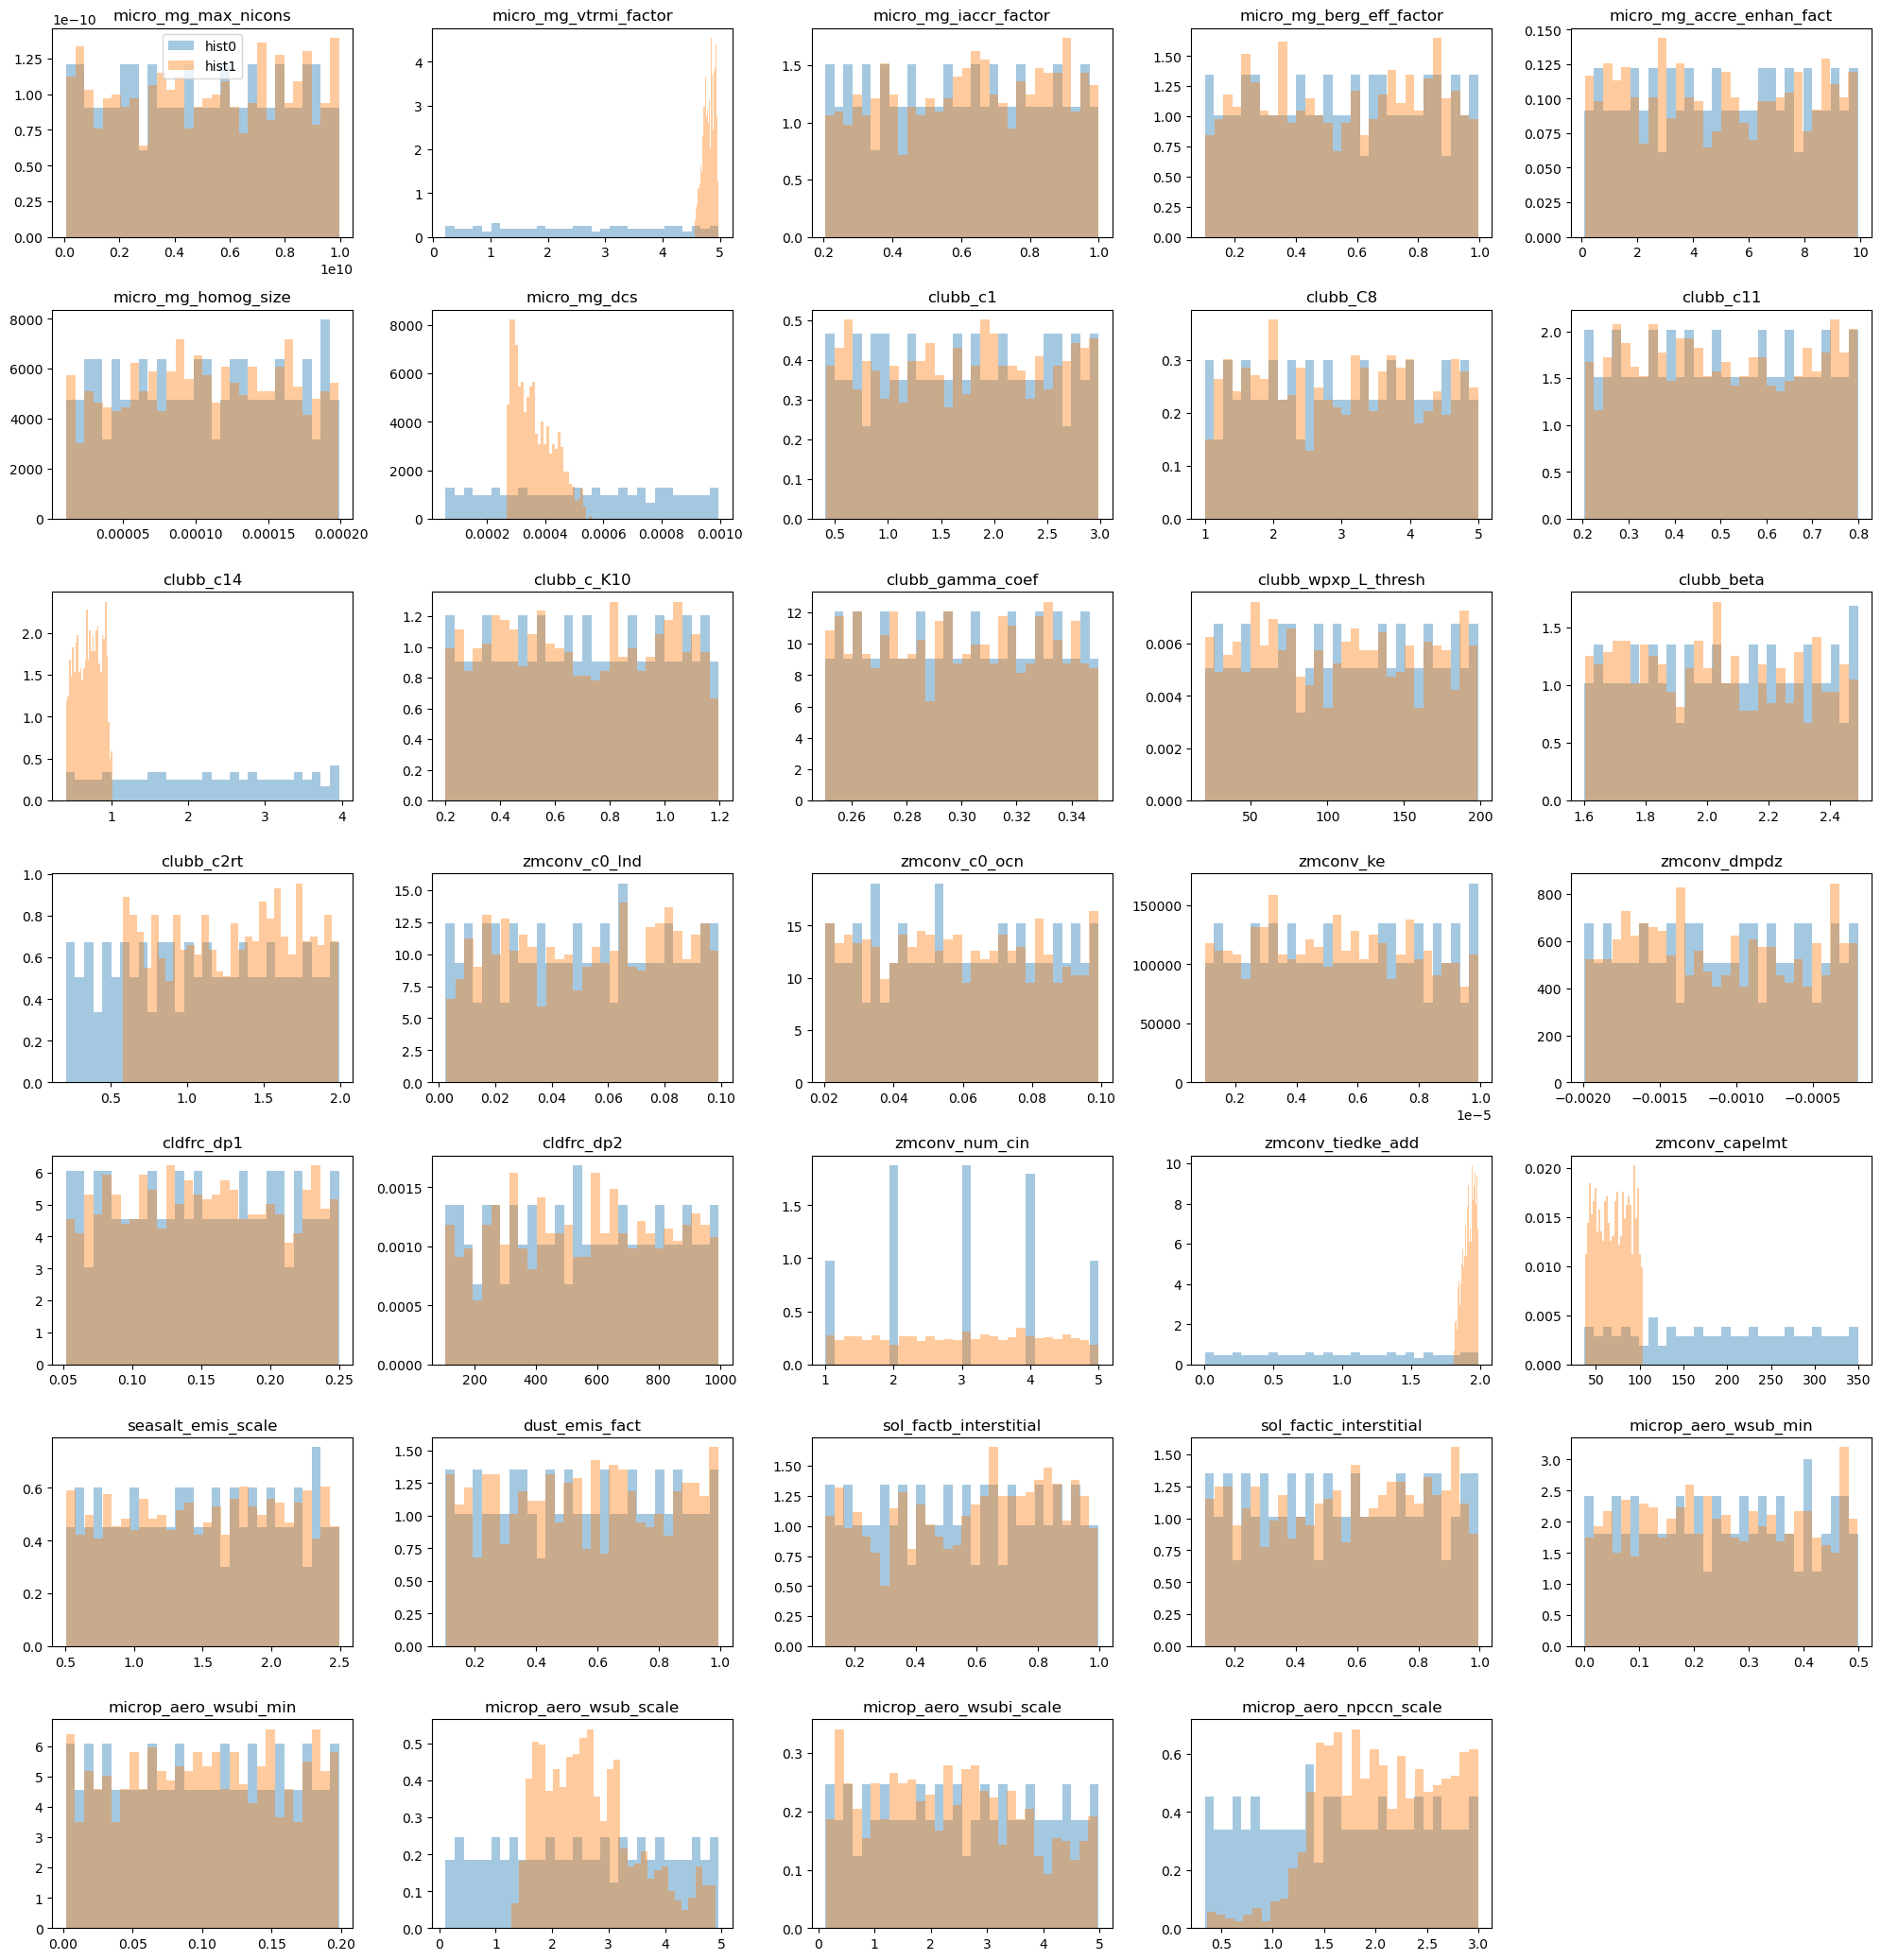

In [27]:
test_case.compare_with_original()

In [29]:
(test_case.results.unscaled_samples.max() - test_case.results.unscaled_samples.min()).prod()

4.628523259981454e-05